# Treinamento do Modelo

# Variáveis

In [1]:
input_dataset = '/home/ifpb/git/teste/train-dataset.csv'
test_datasets = ['/home/ifpb/git/teste/test-dataset.csv', '/home/ifpb/git/teste/test-dataset.csv']
output_dir = '/home/ifpb/git/teste'
features = ['frame_size', 'ipi', 'tos', 'window']
model_parameters = {'max_depth': 10}

## Importando bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy import stats

# Funções

In [3]:
def removeAtributoscomMesmoValor(dataset):

    dataset.drop(columns=dataset.columns[dataset.nunique()==1], inplace=True)

    return dataset

In [4]:
def removeOutliers(dataset):

    # detect and remove outliers
    z_scores = stats.zscore(dataset)
    abs_z_scores = np.abs(z_scores)
    filtered_entries = (abs_z_scores < 5).all(axis=1)
    dataset = dataset[filtered_entries]
    # reset index
    #dataset = dataset.reset_index(drop=True)

    return dataset

In [5]:
def removeDadosFaltantes(dataset):

    dataset=dataset.dropna()
    return dataset

In [6]:
def normalization(X):

    scaler = sk.preprocessing.StandardScaler().fit(X)
    X = scaler.transform(X)
    return X

In [7]:
def test_model(model, X, y, plot_matrix=False, img_name="confusion_matrix"):
  y_pred = model.predict(X)

  accuracy = accuracy_score(y, y_pred)
  precision = precision_score(y, y_pred, average="weighted")
  recall = recall_score(y, y_pred, average="weighted")
  f1 = f1_score(y, y_pred, average="weighted")

  cm = confusion_matrix(y, y_pred)

  # Display metrics
  print("\n" + "="*50)
  print("MODEL PERFORMANCE METRICS")
  print("="*50)
  print(f"Accuracy:  {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall:    {recall:.4f}")
  print(f"F1-Score:  {f1:.4f}")

  print("\n" + "="*50)
  print("DETAILED CLASSIFICATION REPORT")
  print("="*50)
  print(classification_report(y, y_pred))

  print("\n" + "="*50)
  print("CONFUSION MATRIX")
  print("="*50)
  print(cm)

  # Feature importance
  feature_importance = pd.DataFrame({
      'feature': X.columns,
      'importance': model.feature_importances_
  }).sort_values('importance', ascending=False)

  print("\n" + "="*50)
  print("FEATURE IMPORTANCE")
  print("="*50)
  print(feature_importance)

  if plot_matrix:
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y),
                yticklabels=np.unique(y))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{img_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
def n_test_model(model, datasets: list):
    for i,dataset in enumerate(datasets, 1):
        Xt = dataset[features]
        yt = dataset[target]
        test_model(model, Xt, yt, True, f"confusion_matrix_test_data_{i}")
        print(20 * '/n')

In [10]:
def import_csv(file, show_info=False):
  data = pd.read_csv(file)

  # data.dropna(subset=["flags"], inplace=True)

  # data = removeAtributoscomMesmoValor(data)
  data = removeDadosFaltantes(data)
  # data["IPI"] = removeOutliers(data["IPI"])

  if show_info:
    print("Info:")
    data.info()
    print("\nDescrição estatística:")
    print(data.describe())
    print("\nValores nulos:")
    print(data.isnull().sum())
    print("\nDistribuição da target:")
    print(data['classification'].value_counts())
    # print(data["Flags"].value_counts())

  return data

## Importação dos dados

In [11]:
data = import_csv(input_dataset, True)

Info:
<class 'pandas.DataFrame'>
Index: 59963 entries, 0 to 112805
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flow_key        59963 non-null  int64  
 1   srcip           59963 non-null  str    
 2   dstip           59963 non-null  str    
 3   sport           59963 non-null  int64  
 4   dport           59963 non-null  int64  
 5   proto           59963 non-null  int64  
 6   version         59963 non-null  int64  
 7   ihl             59963 non-null  int64  
 8   tos             59963 non-null  int64  
 9   length          59963 non-null  int64  
 10  id              59963 non-null  int64  
 11  frag            59963 non-null  int64  
 12  ttl             59963 non-null  int64  
 13  chksum          59963 non-null  int64  
 14  seq             59963 non-null  int64  
 15  ack             59963 non-null  int64  
 16  window          59963 non-null  int64  
 17  dataofs         59963 non-null  int64  


In [12]:
target = "classification"

X = data[features]
y = data[target]

# Treino do modelo

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

model = DecisionTreeClassifier(random_state=42, **model_parameters)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

## Teste do modelo

### Com base de treinos


MODEL PERFORMANCE METRICS
Accuracy:  0.9949
Precision: 0.9954
Recall:    0.9949
F1-Score:  0.9951

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38041
         1.0       0.72      0.87      0.79       494
         2.0       0.94      0.87      0.90      1186
         3.0       1.00      1.00      1.00      8249

    accuracy                           0.99     47970
   macro avg       0.91      0.93      0.92     47970
weighted avg       1.00      0.99      1.00     47970


CONFUSION MATRIX
[[38024     9     5     3]
 [    0   430    64     0]
 [    0   153  1033     0]
 [    4     6     0  8239]]

FEATURE IMPORTANCE
      feature  importance
3      window    0.628340
1         ipi    0.270404
0  frame_size    0.101256
2         tos    0.000000


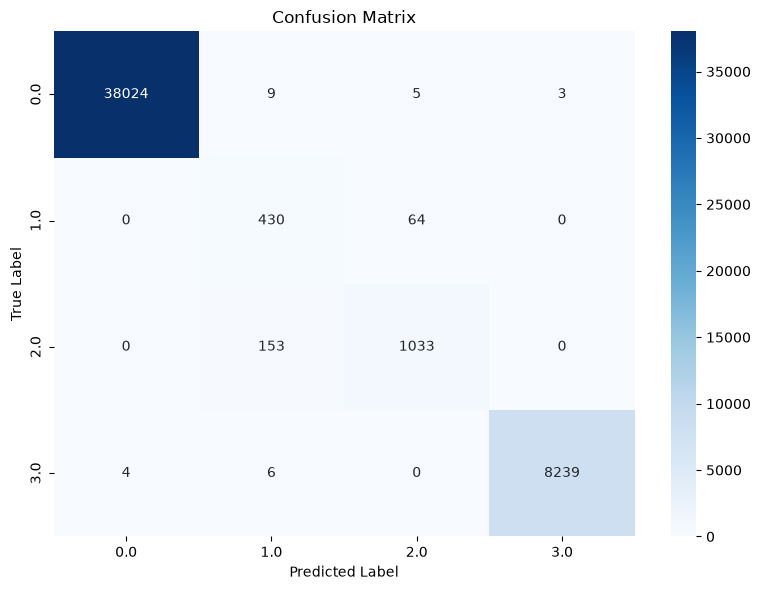

In [14]:
test_model(model, X_train, y_train, True, "confusion_matrix_train_data")

### Com base de validação


MODEL PERFORMANCE METRICS
Accuracy:  0.9920
Precision: 0.9928
Recall:    0.9920
F1-Score:  0.9923

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9499
         1.0       0.64      0.81      0.71       126
         2.0       0.89      0.83      0.86       293
         3.0       1.00      1.00      1.00      2075

    accuracy                           0.99     11993
   macro avg       0.88      0.91      0.89     11993
weighted avg       0.99      0.99      0.99     11993


CONFUSION MATRIX
[[9484    7    4    4]
 [   0  102   24    0]
 [   1   49  242    1]
 [   2    2    2 2069]]

FEATURE IMPORTANCE
      feature  importance
3      window    0.628340
1         ipi    0.270404
0  frame_size    0.101256
2         tos    0.000000


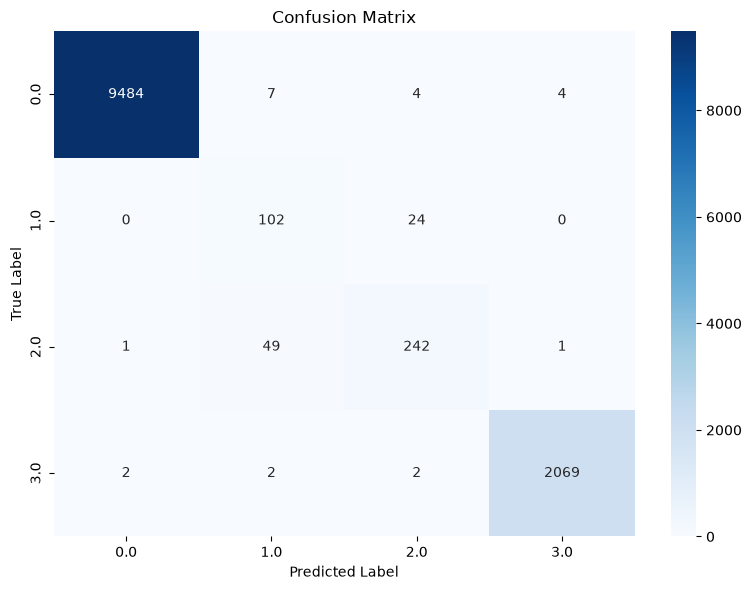

In [15]:
test_model(model, X_test, y_test, True, "confusion_matrix_validation_data")

### Com base de teste

In [16]:
n_test_model(model, test_datasets)

TypeError: string indices must be integers, not 'list'

# Exportar Modelo

In [ ]:
import pickle

with open(f"{output_dir}/tree.pkl", "wb") as f:
  pickle.dump(model, f)